# 4D-STEM affine drift correction and Figure 6 reproduction

Correct the two orthogonal gold 4D-STEM scans used by publication Figure 6.
QuantEM estimates affine scan drift from full-detector virtual images, applies
the same scan-coordinate correction to diffraction patterns and dark-field
virtual images, and rotates the 90° scan into the 0° reference frame before
combining them. Detector coordinates are never warped.

This tutorial and its publication artifact use the **affine-corrected
checkpoint** as the final result.

## Environment

Install the reviewed paper API and latest published `quantem.widget` release
candidate. One notebook supports both interactive and static/report output:

```bash
python -m pip install --upgrade \
  "git+https://github.com/bobleesj/quantem.git@drift-paper"
python -m pip install --pre --upgrade \
  --index-url https://test.pypi.org/simple \
  --extra-index-url https://pypi.org/simple quantem.widget
```

## Data

Download the [raw gold 4D-STEM data](https://drive.google.com/drive/folders/1--5UhA1nF6Q0k-wPMjjowjvlJmnHm2t7?usp=sharing)
and place all HDF5 files in `data/gold_4dstem/`. The shared folder contains
only original acquisitions; this notebook generates correction results and
virtual images locally.

In [1]:
from pathlib import Path

import numpy as np

from quantem.gpu.detector import mean_dp
import quantem.widget as qw
from quantem.gpu.io import load
from quantem.imaging import DriftCorrection
from quantem.widget import Show2D

# Raw masters and AutoSerialized results share DATA (run from tutorials/).
DATA = Path("data/gold_4dstem")
RESULT = DATA / "drift.zip"
VIRTUAL = DATA / "virtual_images.npz"
PIXEL_SIZE_NM = 0.29771

## Inspect the automatically selected compute backend

In [2]:
# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"
WIDGET_MODE = "interactive" if INTERACTIVE else "report"

qw.profile()

quantem.widget  0.0.1rc37
  install       published package
quantem.gpu     0.0.1rc6
  install       source override (differs from installed metadata)
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=0)
  GPU0           25.7 used / 102 GB  (76 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## 1. Load the two native acquisitions

The ARINA masters contain the detector counts but do not contain calibrated
scan sampling or scan-rotation metadata. The acquisition record identifies
`gold_019` as 0° and `gold_020` as 90°. Their transferred real-space
calibration is **0.29771 nm/pixel**, derived from the 76.214 nm Velox field of
view at the same 1.30 Mx magnification divided by the native 256-pixel scan.

The raw maxima are 4750 and 4408 counts, so the loader explicitly preserves
`uint16`; `uint8` would clip measured detector counts.

In [3]:
loaded_0 = load(
    DATA / "gold_019_master.h5",
    backend="auto",
    dtype="uint16",
    auto_narrow=False,
    output="torch",
    verbose=False,
)
loaded_90 = load(
    DATA / "gold_020_master.h5",
    backend="auto",
    dtype="uint16",
    auto_narrow=False,
    output="torch",
    verbose=False,
)
scan_0, scan_90 = loaded_0.data, loaded_90.data
print(f"0° scan:  {tuple(scan_0.shape)}, {scan_0.dtype}")
print(f"90° scan: {tuple(scan_90.shape)}, {scan_90.dtype}")

0° scan:  (256, 256, 192, 192), torch.uint16
90° scan: (256, 256, 192, 192), torch.uint16


## 2. Solve the affine scan drift

`correct_affine()` automatically selects normalization, padding, translation
bounds, broad-search downsampling, drift-rate coverage, and full-resolution
refinement. No explicit preprocessing or search-grid tuning is required.

In [4]:
drift = DriftCorrection.from_4dstem(
    scan_0,
    scan_90,
    scan_direction_degrees=(0, 90),
    scan_sampling=PIXEL_SIZE_NM,
    scan_units="nm",
)
drift.correct_affine(
    show_combined=False,
    show_scans=False,
    verbose=True,
)

correct_affine: prepared scanline knots automatically; padding=0.5, canvas=(384, 384), 0.22 s


correct_affine: automatic pyramid 8x, 5 native candidates, 0.26 s
Drift: (+0.02656, -0.12344) px/line; translation bound 64.0 px


## 3. Inspect the full-detector virtual images

The drift object owns the raw/corrected orientation, labels, calibration, and
panel order.

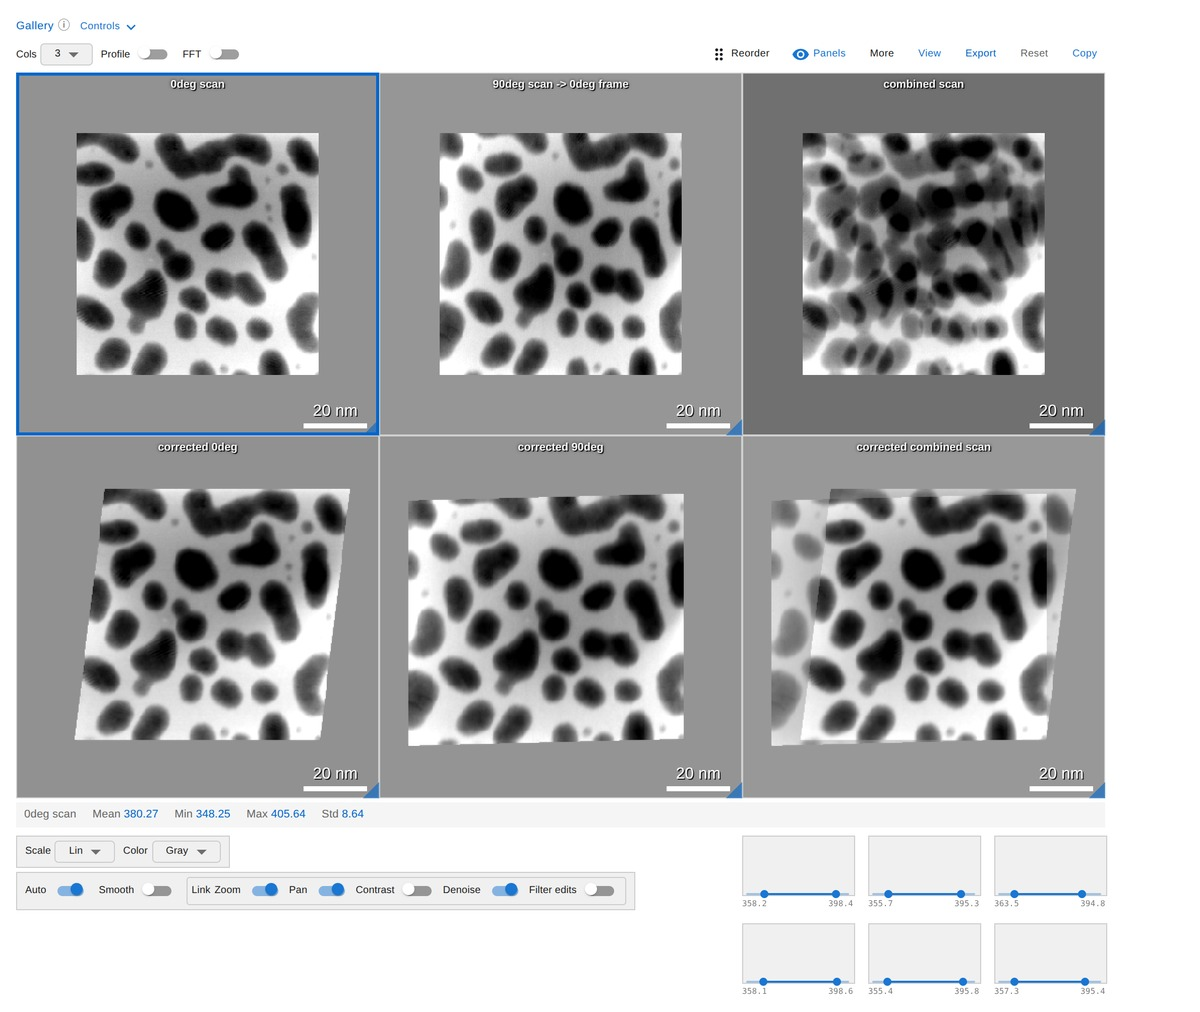

In [5]:
virtual_view = drift.show(
    mode=VIEW_MODE,
    cmap="gray",
    auto_contrast=True,
    link_contrast=False,
    show_fft=False,
    size=360,
)
virtual_view

## 4. Verify the correction quantitatively

Every NCC value uses the same final common-coverage mask. Padding and pixels
not measured by both scans cannot inflate the apparent improvement.

In [6]:
quality = drift.report()
quality

,Common NCC,Top third,Middle third,Bottom third,Coverage
Mutual stage,,,,,
before,0.071651,-0.166413,-0.049514,0.16545,0.933121
affine,0.952219,0.966834,0.958855,0.97699,0.933121


## 5. Browse all three 4D-STEM processing stages

`show_4dstem()` constructs one labeled viewer containing the raw 0° dataset,
the affine-corrected 0° dataset, and the affine-corrected 0°/90°
diffraction-pattern average. `det_bin=4` affects only this browse copy.

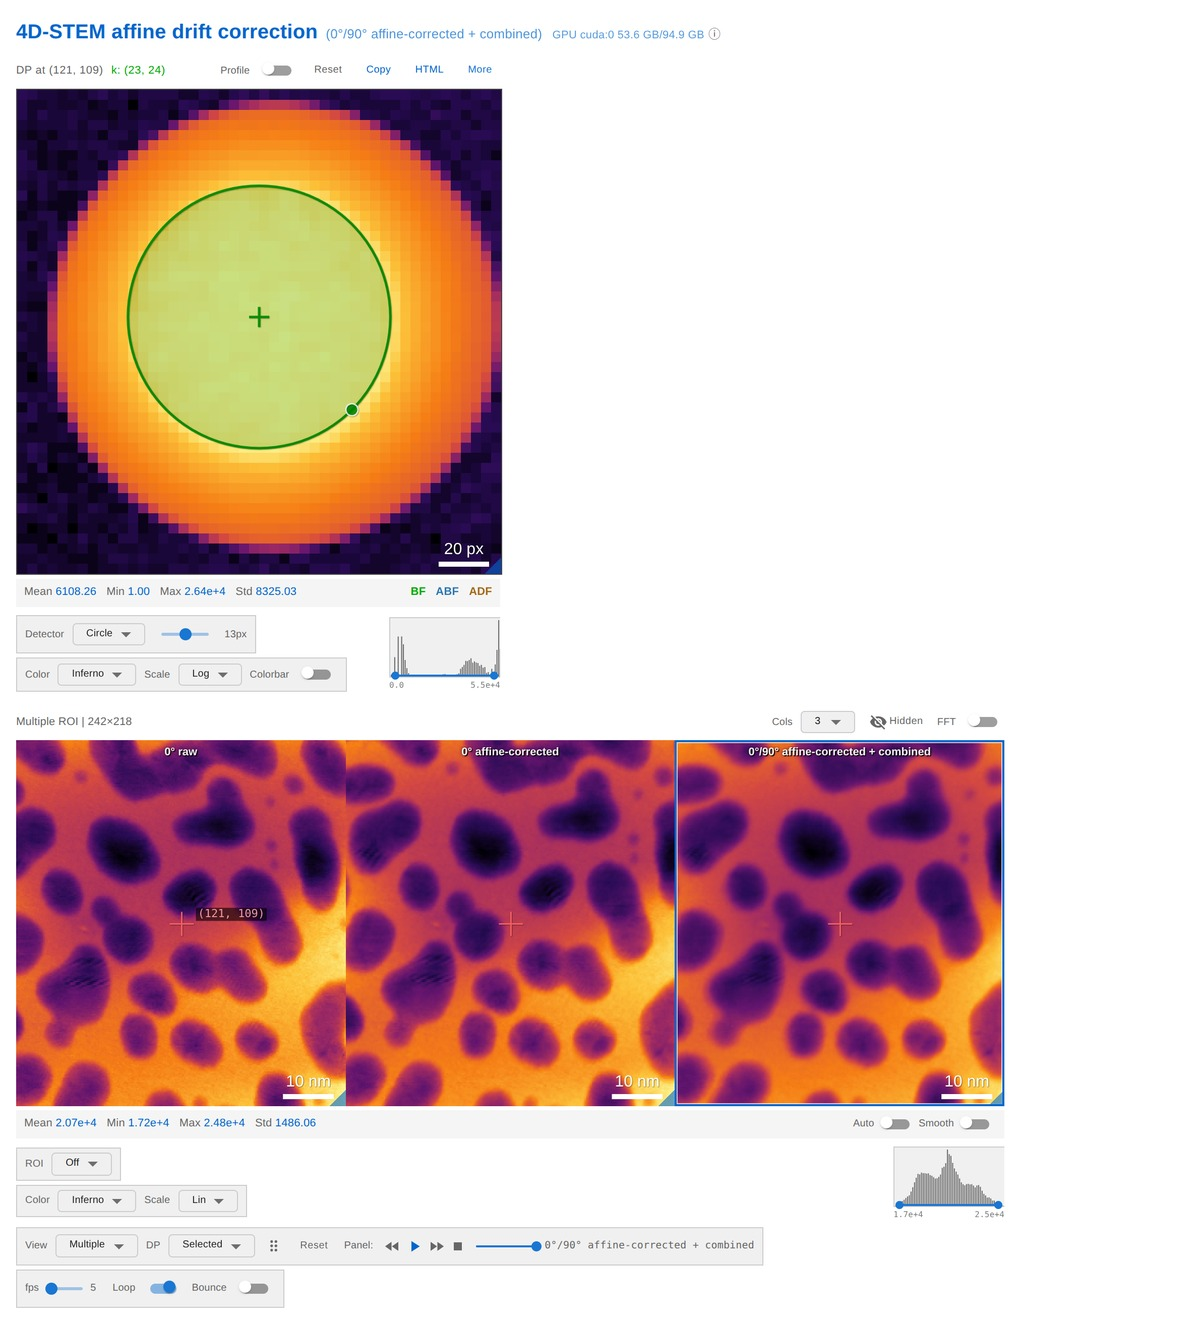

In [7]:
diffraction_view = drift.show_4dstem(
    det_bin=4,
    view_mode="multiple",
    ui_mode=WIDGET_MODE,
)
diffraction_view

## 6. Dark-field panels

Build the dark-field mask from the mean diffraction pattern (pixels outside
1.5× the bright-field-disk radius), integrate both scans, and apply the
learned drift field.

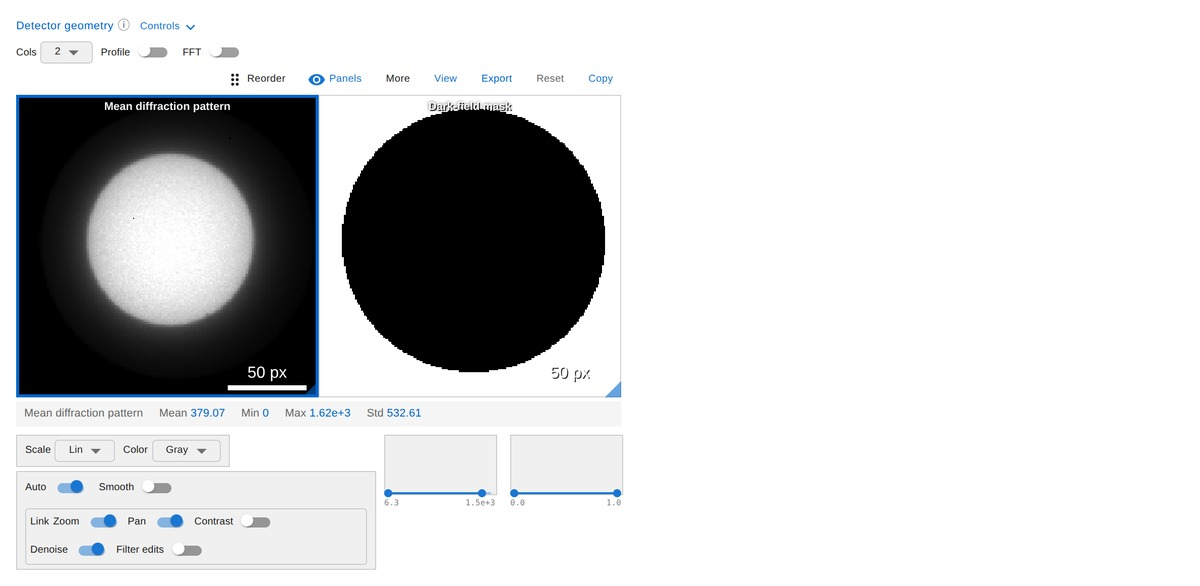

In [8]:
mean_diffraction = np.asarray(mean_dp(scan_0), dtype=np.float64)
rows, columns = np.indices(mean_diffraction.shape)
weights = mean_diffraction
center_row = float((rows * weights).sum() / weights.sum())
center_column = float((columns * weights).sum() / weights.sum())
bright_field_radius = float(
    np.sqrt((mean_diffraction > 0.25 * mean_diffraction.max()).sum() / np.pi)
)
radius = np.hypot(rows - center_row, columns - center_column)
df_mask = radius >= 1.5 * bright_field_radius

detector_view = Show2D(
    [mean_diffraction.astype(np.float32), df_mask.astype(np.float32)],
    labels=["Mean diffraction pattern", "Dark-field mask"],
    title="Detector geometry",
    cmap="gray",
    ncols=2,
    auto_contrast=True,
    link_contrast=False,
    show_fft=False,
    ui_mode=WIDGET_MODE,
)
detector_view

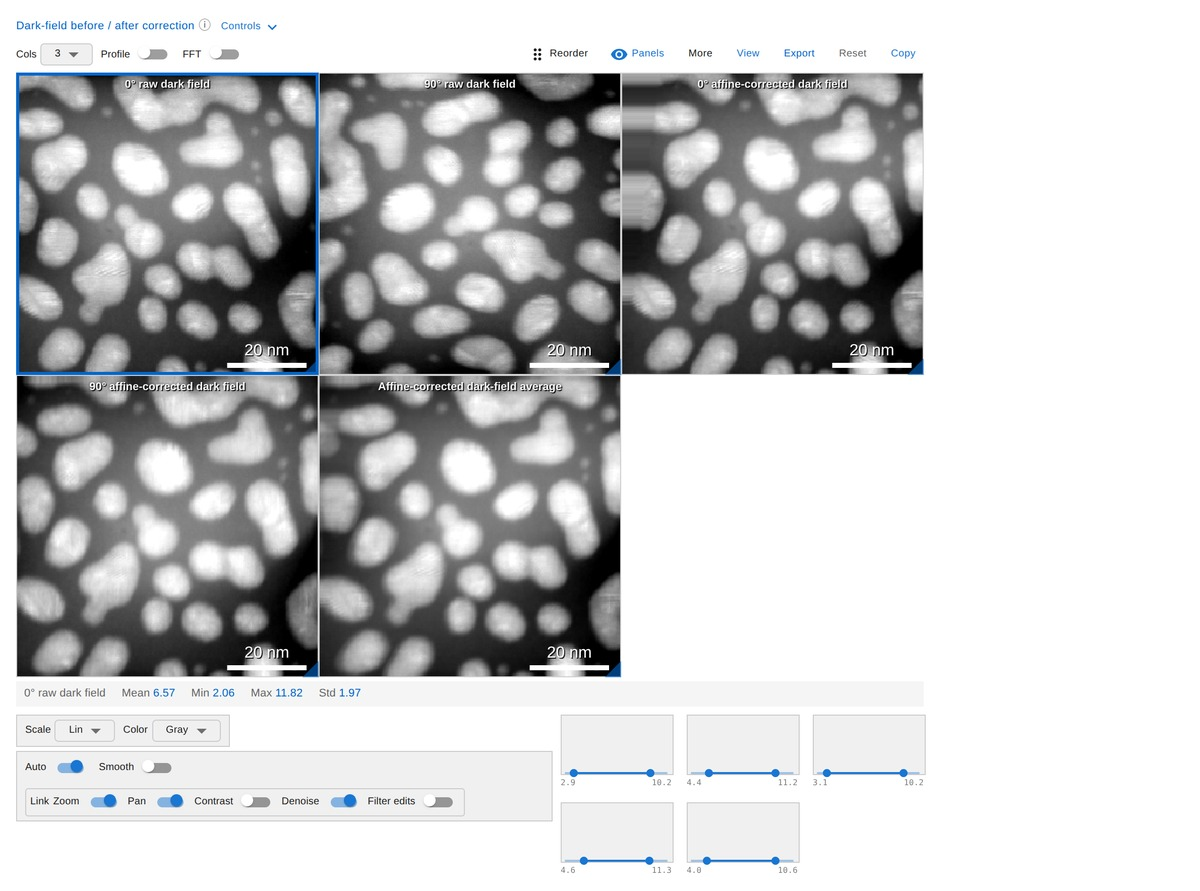

In [9]:
df_0 = drift.integrate_virtual_detector(scan_0, df_mask, reduce="mean")
df_90 = drift.integrate_virtual_detector(scan_90, df_mask, reduce="mean")
corrected_df = drift.corrected_virtual_images(df_0, df_90)

df_view = Show2D(
    [
        df_0,
        df_90,
        corrected_df["corrected_image_0"],
        corrected_df["corrected_image_1"],
        corrected_df["corrected_image"],
    ],
    labels=[
        "0° raw dark field",
        "90° raw dark field",
        "0° affine-corrected dark field",
        "90° affine-corrected dark field",
        "Affine-corrected dark-field average",
    ],
    title="Dark-field before / after correction",
    cmap="gray",
    ncols=3,
    sampling=PIXEL_SIZE_NM,
    units="nm",
    auto_contrast=True,
    link_contrast=False,
    show_fft=False,
    ui_mode=WIDGET_MODE,
)
df_view

## 7. Save the full solved object

AutoSerialize the `DriftCorrection` next to the raw masters. A small companion
NPZ stores the dark-field mask and corrected virtual images so Figure 6 can
rebuild without loading the multi-gigabyte diffraction cubes.

In [10]:
DATA.mkdir(parents=True, exist_ok=True)
drift.save(RESULT, mode="o")
np.savez_compressed(
    VIRTUAL,
    vi0=df_0,
    vi90=df_90,
    df_mask=df_mask.astype(np.float32),
    corrected__corrected_image=corrected_df["corrected_image"],
    corrected__corrected_image_0=corrected_df["corrected_image_0"],
    corrected__corrected_image_1=corrected_df["corrected_image_1"],
)
print(f"Drift object:  {RESULT}")
print(f"Virtual images: {VIRTUAL}")

Drift object:  data/gold_4dstem/drift.zip
Virtual images: data/gold_4dstem/virtual_images.npz


## Full-resolution corrected diffraction data (optional)

The publication figure needs only the solved drift object and corrected
dark-field images above. To materialize the complete native-detector
correction for downstream diffraction analysis, run:

```python
full = drift.corrected_4dstem(verbose=True)
full.corrected_4dstem      # merged diffraction-pattern dataset
full.corrected_4dstem_0    # corrected 0° dataset
full.corrected_4dstem_1    # corrected 90° dataset in the 0° frame
```

This allocation is intentionally not part of the default tutorial run.

## Continue with advanced tutorials

- **Explicit affine examples:** `advanced/2d_affine_explicit_*.ipynb`
- **Affine diagnostics:** `advanced/2d_affine_diagnostics_ws2_0070_0071.ipynb`

## Reproduce publication Figure 6

After this notebook finishes, the figure notebook reads the generated data
contract without loading the raw 4D-STEM cubes:

```bash
cd figure
jupyter nbconvert --to notebook --execute --inplace fig6_4d_stem.ipynb
```

The generated artifact is the same affine-corrected checkpoint inspected
interactively above.